# 4주차: 다층 신경망 (MLP) — 은닉층, 활성화 함수, XOR 해결

> **수업 구성**
> - Part 1 (강의 영상 ~40분): 이론 설명 — 미리 보고 오세요
> - Part 2 (교실 실습 100분): 빈칸 채우기 실습

---

## 0. 지난 주 복습 & 이번 주 연결

3주차에서 우리는 **PyTorch의 핵심 학습 루프**를 익혔습니다.

```
optimizer.zero_grad()        # gradient 초기화
output = model(x)            # forward pass
loss = criterion(output, y)  # loss 계산
loss.backward()              # backward (autograd)
optimizer.step()             # 가중치 업데이트
```

3주차 모델은 `nn.Linear(input_dim, 1)` — **은닉층 없이** 입력에서 출력으로 바로 연결했습니다.

이번 주 핵심 질문: **은닉층을 끼워 넣으면 무슨 일이 일어날까요?**

> 💡 학습 루프 코드는 **전혀 바뀌지 않습니다.** 모델 구조만 바뀝니다.


## 1. 왜 은닉층이 필요한가? — XOR 문제

2주차에서 로지스틱 회귀로 XOR을 풀려다 실패했던 것 기억하시나요?

| x₁ | x₂ | y (XOR) |
|----|----|---------|
| 0  | 0  | 0       |
| 0  | 1  | 1       |
| 1  | 0  | 1       |
| 1  | 1  | 0       |

로지스틱 회귀는 **직선 하나**로 분류합니다.
XOR은 직선 하나로 두 클래스를 나눌 수 없는 **선형 분리 불가능** 문제입니다.


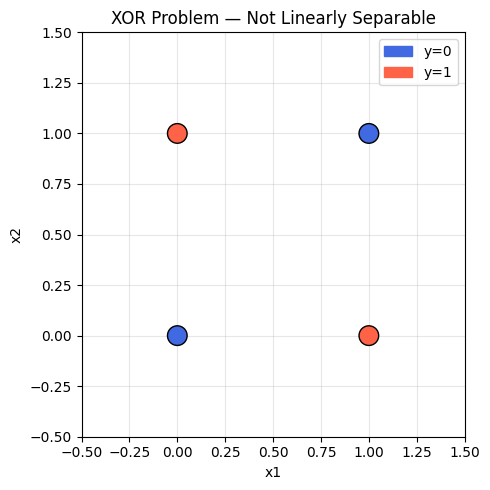

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

torch.manual_seed(42)
np.random.seed(42)

X_xor = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y_xor = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)

fig, ax = plt.subplots(figsize=(5,5))
colors = ['royalblue' if label == 0 else 'tomato' for label in y_xor.squeeze()]
ax.scatter(X_xor[:,0], X_xor[:,1], c=colors, s=200, zorder=5, edgecolors='black')
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_xlabel("x1"); ax.set_ylabel("x2")
ax.set_title("XOR Problem — Not Linearly Separable")
ax.legend(handles=[mpatches.Patch(color='royalblue', label='y=0'),
                   mpatches.Patch(color='tomato',    label='y=1')])
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 2. MLP 구조 — 은닉층을 추가하자

**MLP(Multi-Layer Perceptron)** 는 입력층과 출력층 사이에 **은닉층(hidden layer)** 을 하나 이상 추가한 신경망입니다.

### 이번 주 구조 (1개 은닉층), 전체 2-layer network

```
입력층  →  은닉층  →  출력층
(n개)      (h개)      (1개)
```

### Forward Pass 차원 흐름

입력: $X \in \mathbb{R}^{m \times n}$ (m: 샘플 수, n: 특성 수)

| 단계 |&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;  연산 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 입력 shape | 출력 shape | &nbsp;&nbsp;파라메터(W, b)&nbsp;&nbsp; |
|------|--------------|------|-----------|-----------|
| 1층 선형 |$Z^{[1]} = X W_1^T + b_1 $  | $(m, n)$ | $(m, h)$ | $n \times h + h $ |
| 1층 활성화 | $A^{[1]} = g\!\left(Z^{[1]}\right)$ | $(m, h)$ | $(m, h)$ |$   $ |
| 2층 선형 | $Z^{[2]} = A^{[1]} W_2^T + b_2$ |  $(m, h)$ | $(m, 1)$ | $h \times 1 + 1 $ |
| 2층 활성화 |$\hat{y}= \sigma\!\left(Z^{[2]}\right)$  | $(m, 1)$ | $(m, 1)$ |$  $ |


> PyTorch의 `nn.Linear(n, h)`는 내부적으로 $W \in \mathbb{R}^{h \times n}$, $b \in \mathbb{R}^{h}$ 를 관리합니다.


## 3. 활성화 함수(activation function) — 왜 반드시 필요한가?

### 활성화 함수가 없다면?

은닉층을 아무리 쌓아도 결국 **하나의 선형 변환**과 동일합니다.

$$Z^{[2]} = (X W_1^T)\, W_2^T = X\,(W_1 W_2)^T$$

즉, $W_1 W_2$ 라는 새 행렬 하나로 합쳐져 버립니다. → 은닉층이 아무 의미가 없습니다!

### 주요 활성화 함수

| 이름 |&nbsp;&nbsp;&nbsp;&nbsp; 범위&nbsp;&nbsp;&nbsp;&nbsp; | &nbsp;&nbsp;&nbsp;&nbsp; 수식 &nbsp;&nbsp;&nbsp;&nbsp; |특징 |
|------|------|------|------|
| Sigmoid | $(0,\ 1)$ | $$\sigma(z) = \frac{1}{1+e^{-z}}$$ | 출력층 이진분류에 사용 |
| Tanh | $(-1,\ 1)$ |$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$$ | 은닉층에서 Sigmoid보다 성능 ↑ |
| ReLU | $[0,\ \infty)$ | $\text{ReLU}(z) = \max(0,\, z)$| 현재 가장 많이 쓰임, 빠른 학습 |



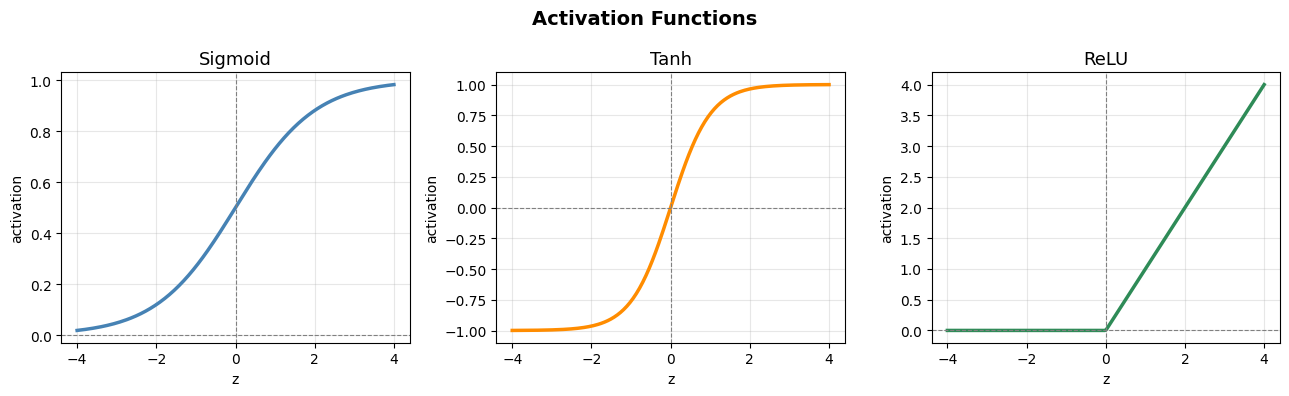

In [2]:
z = torch.linspace(-4, 4, 200)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, y, name, color in zip(
        axes,
        [torch.sigmoid(z), torch.tanh(z), torch.relu(z)],
        ['Sigmoid', 'Tanh', 'ReLU'],
        ['steelblue', 'darkorange', 'seagreen']):
    ax.plot(z.numpy(), y.numpy(), color=color, lw=2.5)
    ax.axhline(0, color='gray', lw=0.8, linestyle='--')
    ax.axvline(0, color='gray', lw=0.8, linestyle='--')
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('z'); ax.set_ylabel('activation')
    ax.grid(True, alpha=0.3)

plt.suptitle("Activation Functions", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


### 어떤 활성화 함수를 쓸까?

- **은닉층**: ReLU를 기본으로 사용 (학습이 빠르고 Vanishing Gradient 완화)
- **출력층**: 문제 유형에 따라
  - 이진분류 → Sigmoid
  - 다중분류 → Softmax (8주차)
  - 회귀 → 없음 (선형 출력)

> ⚠️ **Vanishing Gradient**: Sigmoid/Tanh는 입력이 매우 크거나 작으면 기울기가 0에 가까워집니다.
> 역전파 시 앞쪽 레이어로 gradient가 거의 전달되지 않아 학습이 멈춥니다. → 6주차에서 자세히 다룹니다.


## 4. 가중치 초기화 — 왜 랜덤으로 해야 할까?

### Zero 초기화의 문제점: Symmetry

모든 가중치를 0으로 초기화하면 **모든 뉴런이 동일한 gradient를 받습니다.**

$$\frac{\partial L}{\partial W_1^{(i)}} = \frac{\partial L}{\partial W_1^{(j)}} \quad \forall\, i, j$$

→ 학습 내내 모든 은닉 뉴런이 완전히 동일하게 유지됩니다. 은닉층이 있으나 마나입니다!

### 해결: 랜덤 초기화

작은 랜덤값으로 초기화하면 각 뉴런이 서로 다른 특성을 학습합니다.
`nn.Linear`는 기본적으로 **Kaiming Uniform** 초기화를 사용합니다.


In [3]:
torch.manual_seed(0)

w_zero = torch.zeros(3, 2)
print("Zero init (all rows identical):")
print(w_zero)

w_rand = torch.randn(3, 2) * 0.01
print("\nRandom init (each row different):")
print(w_rand.round(decimals=4))


Zero init (all rows identical):
tensor([[0., 0.],
        [0., 0.],
        [0., 0.]])

Random init (each row different):
tensor([[ 0.0154, -0.0029],
        [-0.0218,  0.0057],
        [-0.0108, -0.0140]])


## 5. PyTorch로 MLP 구현하기

### 방법 1: `nn.Sequential`

```python
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)
```

### 방법 2: `nn.Module` 상속 (확장성 ↑)

```python
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        a1  = torch.relu(self.fc1(x))
        out = torch.sigmoid(self.fc2(a1))
        return out
```

이번 실습에서는 `nn.Module` 방식을 사용합니다.


## 6. XOR 문제 완전 해결

이제 MLP로 XOR 문제를 해결해봅시다.
학습 루프는 3주차와 완전히 동일합니다!


In [4]:
X_xor = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y_xor = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)  #파라메터가 있는 레이어 추가
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        a1  = torch.tanh(self.fc1(x))
        out = torch.sigmoid(self.fc2(a1))
        return out

torch.manual_seed(42)
model_xor = MLP(input_dim=2, hidden_dim=4)
criterion  = nn.BCELoss()
optimizer  = torch.optim.Adam(model_xor.parameters(), lr=0.1)

losses = []
for epoch in range(3000):
    optimizer.zero_grad()
    pred = model_xor(X_xor)
    loss = criterion(pred, y_xor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print(f"Final loss: {losses[-1]:.6f}")
with torch.no_grad():
    preds = model_xor(X_xor)
    for i, (xi, pi) in enumerate(zip(X_xor, preds)):
        label = 1 if pi.item() > 0.5 else 0
        print(f"  x={xi.tolist()} → prob={pi.item():.3f}, pred={label}, true={int(y_xor[i].item())}")


Final loss: 0.000040
  x=[0.0, 0.0] → prob=0.000, pred=0, true=0
  x=[0.0, 1.0] → prob=1.000, pred=1, true=1
  x=[1.0, 0.0] → prob=1.000, pred=1, true=1
  x=[1.0, 1.0] → prob=0.000, pred=0, true=0


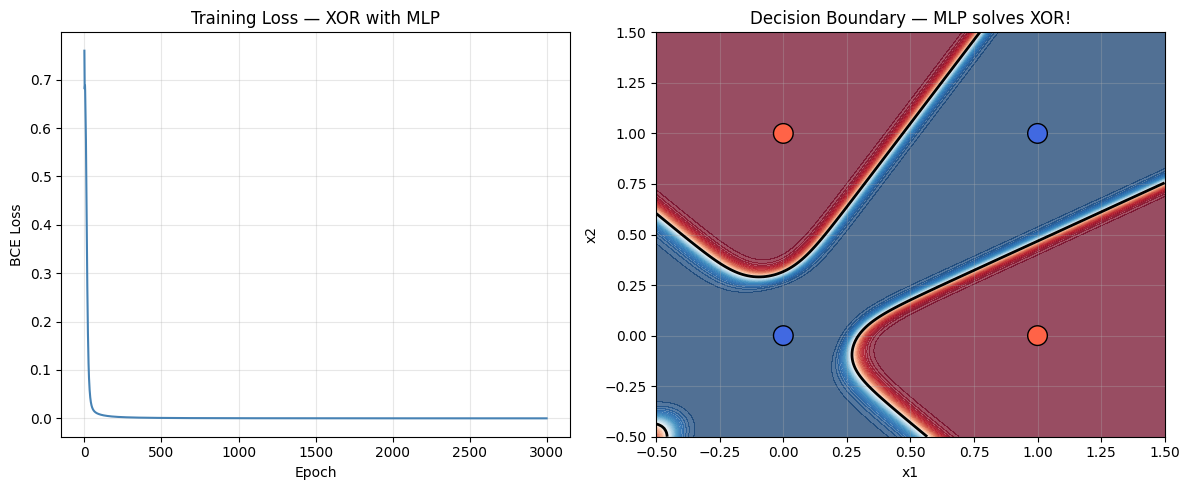

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(losses, color='steelblue', lw=1.5)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Training Loss — XOR with MLP")
axes[0].grid(True, alpha=0.3)

xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    zz = model_xor(grid).reshape(xx.shape).numpy()

axes[1].contourf(xx, yy, zz, levels=50, cmap='RdBu_r', alpha=0.7)
axes[1].contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=2)
colors = ['royalblue' if l == 0 else 'tomato' for l in y_xor.squeeze()]
axes[1].scatter(X_xor[:,0], X_xor[:,1], c=colors, s=200, zorder=5, edgecolors='black')
axes[1].set_title("Decision Boundary — MLP solves XOR!")
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2")
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [6]:
# meshgrid = 1D 축 배열들 → “격자점 좌표표”로 복제해서 2D로 만드는 함수
x1 = [10, 20, 30, 40]   # x1축 값들
x2 = [1, 2, 3]         # x2축 값들

x1s, x2s = np.meshgrid(x1, x2)
print(x1s)
print(x2s)

[[10 20 30 40]
 [10 20 30 40]
 [10 20 30 40]]
[[1 1 1 1]
 [2 2 2 2]
 [3 3 3 3]]


### 결과 해석

MLP는 **비선형 결정경계**를 학습하여 XOR을 완벽하게 분류합니다.

은닉층이 하는 일: 원래 입력 공간을 **새로운 공간으로 변환(representation learning)** 하여
선형 분리가 가능하게 만드는 것입니다.


## 7. 실전 데이터셋 — Moon Dataset

Shape of X_tr (400, 2)
Shape of y_tr (400,)
Test Accuracy: 99.0%


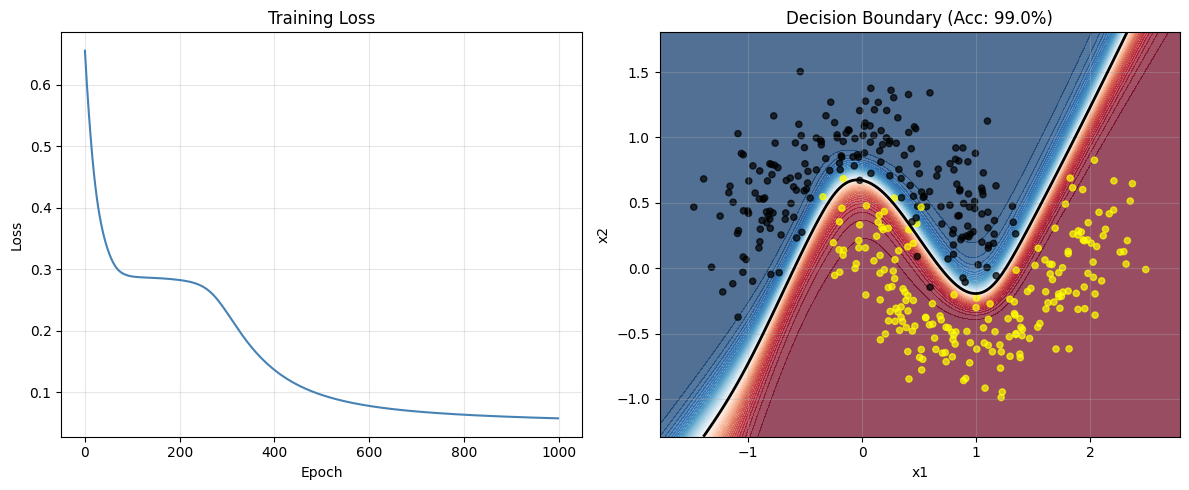

In [7]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X_np, y_np = make_moons(n_samples=500, noise=0.2, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_np, y_np, test_size=0.2, random_state=42)

print('Shape of X_tr', X_tr.shape)
print('Shape of y_tr', y_tr.shape)

X_train = torch.tensor(X_tr, dtype=torch.float32)
y_train = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
X_test  = torch.tensor(X_te, dtype=torch.float32)
y_test  = torch.tensor(y_te, dtype=torch.float32).unsqueeze(1)

torch.manual_seed(42)
model_moon = MLP(input_dim=2, hidden_dim=8)
optimizer  = torch.optim.Adam(model_moon.parameters(), lr=0.01)
criterion  = nn.BCELoss()

train_losses = []
for epoch in range(1000):
    optimizer.zero_grad()
    loss = criterion(model_moon(X_train), y_train)
    loss.backward(); optimizer.step()
    train_losses.append(loss.item())

with torch.no_grad():
    acc = ((model_moon(X_test) > 0.5).float() == y_test).float().mean().item()
print(f"Test Accuracy: {acc*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(train_losses, color='steelblue')
axes[0].set_title("Training Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

xx, yy = np.meshgrid(np.linspace(X_np[:,0].min()-0.3, X_np[:,0].max()+0.3, 200),
                     np.linspace(X_np[:,1].min()-0.3, X_np[:,1].max()+0.3, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    zz = model_moon(grid).reshape(xx.shape).numpy()
axes[1].contourf(xx, yy, zz, levels=50, cmap='RdBu_r', alpha=0.7)
axes[1].contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=2)
axes[1].scatter(X_tr[:,0], X_tr[:,1],
                c=['black' if l==0 else 'yellow' for l in y_tr], s=20, alpha=0.7)
axes[1].set_title(f"Decision Boundary (Acc: {acc*100:.1f}%)")
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2"); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 8. 다음 주 예고 — Deep Neural Network

4주차에서는 **은닉층 1개**짜리 MLP를 공부했습니다.

5주차에서는 은닉층을 **여러 개** 쌓은 **Deep Neural Network**를 다룹니다.

- 레이어를 몇 개나 쌓아야 할까?
- 각 레이어의 뉴런 수는?
- 깊을수록 무조건 좋을까?
- 행렬 차원이 어떻게 흘러가는가?

> 학습 루프는 여전히 그대로입니다. 구조(architecture)만 깊어집니다!

---
**Part 2 실습으로 넘어가세요 ↓**


---
# Part 2: 실습 (교실 100분)

> - `______` (언더바 6개) 를 올바른 코드로 채우세요.
> - [A]는 한 줄, [B]는 여러 줄 채우기입니다.

---

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)


## [A] 한 줄 채우기

---
### A-1. 활성화 함수 직접 구현

아래 수식을 참고하여 PyTorch 내장 함수 없이 직접 구현하세요.

$$\sigma(z) = \frac{1}{1+e^{-z}}, \qquad \tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}, \qquad \text{ReLU}(z) = \max(0,\, z)$$


In [ ]:
z = torch.tensor([-3.0, -1.0, 0.0, 1.0, 3.0])

my_sigmoid = ______
my_tanh    = ______
my_relu    = ______

print("Sigmoid match:", torch.allclose(my_sigmoid, torch.sigmoid(z)))
print("Tanh match:   ", torch.allclose(my_tanh,    torch.tanh(z)))
print("ReLU match:   ", torch.allclose(my_relu,    torch.relu(z)))


---
### A-2. MLP `forward` 완성


In [ ]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        a1  = ______   # fc1 → ReLU
        out = ______   # fc2 → Sigmoid
        return out

model_test = SimpleMLP(input_dim=3, hidden_dim=5)
print("Output shape:", model_test(torch.randn(10, 3)).shape)  # Expected: [10, 1]


---
### A-3. 파라미터 수 계산

구조: `Linear(2→8)` → ReLU → `Linear(8→1)` → Sigmoid

$$\text{Linear}(2 \to 8):\ 2 \times 8 + 8 = ?  \qquad  \text{Linear}(8 \to 1):\ 8 \times 1 + 1 = ?$$


In [ ]:
model_count = nn.Sequential(
    nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid()
)

total_params = ______

print(f"Total trainable parameters: {total_params}")


---
### A-4. BCE Loss 직접 계산

$$\mathcal{L} = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log\hat{y}^{(i)} + (1-y^{(i)})\log(1-\hat{y}^{(i)})\right]$$


In [ ]:
y_true = torch.tensor([1.0, 0.0, 1.0, 1.0, 0.0])
y_pred = torch.tensor([0.9, 0.1, 0.8, 0.6, 0.3])

my_bce = ______

bce_builtin = nn.BCELoss()(y_pred, y_true)
print(f"My BCE:      {my_bce.item():.6f}")
print(f"PyTorch BCE: {bce_builtin.item():.6f}")
print(f"Match: {torch.isclose(my_bce, bce_builtin)}")


---
### A-5. 학습 루프 5단계


In [ ]:
X_xor = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y_xor = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)

torch.manual_seed(0)
model_a5     = SimpleMLP(input_dim=2, hidden_dim=4)
optimizer_a5 = torch.optim.Adam(model_a5.parameters(), lr=0.1)
criterion_a5 = nn.BCELoss()

for epoch in range(500):
    ______          # 1. gradient 초기화
    pred = model_a5(X_xor)
    loss = ______   # 2. loss 계산
    ______          # 3. backward
    ______          # 4. 가중치 업데이트

print(f"Final loss: {loss.item():.5f}")


---
### A-6. `torch.no_grad()` 평가


In [ ]:
with ______:
    predictions      = model_a5(X_xor)
    predicted_labels = (predictions > 0.5).int()

print("Predictions:", predicted_labels.T)
print("True labels:", y_xor.T.int())


---
### A-7. 은닉층 표현(Representation) 추출

$A^{[1]}$ 을 추출하세요. 힌트: `fc1` 까지만 실행 후 ReLU 적용


In [ ]:
with torch.no_grad():
    A1 = ______

print("Hidden representation shape:", A1.shape)
for xi, ai in zip(X_xor, A1):
    print(f"  x={xi.tolist()} → A1={ai.numpy().round(3)}")


---
### A-8. ReLU vs Tanh 성능 비교


In [ ]:
results = {}
X_xor = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y_xor = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)

for act_name in ['relu', 'tanh']:
    torch.manual_seed(42)
    act_layer = ______   # nn.ReLU() 또는 nn.Tanh()
    model_act = nn.Sequential(nn.Linear(2, 8), act_layer, nn.Linear(8, 1), nn.Sigmoid())
    opt = torch.optim.Adam(model_act.parameters(), lr=0.1)
    for _ in range(500):
        opt.zero_grad(); l = nn.BCELoss()(model_act(X_xor), y_xor); l.backward(); opt.step()
    results[act_name] = l.item()

for name, loss_val in results.items():
    print(f"{name:6s} final loss: {loss_val:.6f}")


---
## [B] 여러 줄 채우기

---
### B-1. Moon 데이터셋 전체 파이프라인

**목표: Test Accuracy ≥ 85%**


In [ ]:
X_np, y_np = make_moons(n_samples=600, noise=0.25, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_np, y_np, test_size=0.2, random_state=42)

X_train = torch.tensor(X_tr, dtype=torch.float32)
y_train = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
X_test  = torch.tensor(X_te, dtype=torch.float32)
y_test  = torch.tensor(y_te, dtype=torch.float32).unsqueeze(1)

torch.manual_seed(42)
model_b1     = ______
criterion_b1 = ______
optimizer_b1 = ______

train_losses_b1 = []
for epoch in range(______):
    ______; ______; ______; ______; ______
    train_losses_b1.append(loss.item())

with torch.no_grad():
    ______; ______

print(f"Test Accuracy: {acc*100:.1f}%")


In [ ]:
# 시각화 (빈칸 없음)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(train_losses_b1, color='steelblue')
axes[0].set_title("Training Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

xx, yy = np.meshgrid(np.linspace(X_np[:,0].min()-0.5, X_np[:,0].max()+0.5, 200),
                     np.linspace(X_np[:,1].min()-0.5, X_np[:,1].max()+0.5, 200))
grid_b1 = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    zz = model_b1(grid_b1).reshape(xx.shape).numpy()
axes[1].contourf(xx, yy, zz, levels=50, cmap='RdBu_r', alpha=0.7)
axes[1].contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=2)
axes[1].scatter(X_tr[:,0], X_tr[:,1],
                c=['royalblue' if l==0 else 'tomato' for l in y_tr], s=20, alpha=0.7)
axes[1].set_title(f"Decision Boundary (Acc: {acc*100:.1f}%)")
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2"); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
### B-2. (숙제 가능) Zero Init vs Random Init 실험

**가설**: Zero 초기화를 사용하면 MLP가 XOR을 풀지 못한다.

힌트:
- `model.fc1.weight.data.fill_(0)` 으로 0 초기화
- 두 모델을 같은 조건으로 학습 후 Loss 곡선과 예측 결과를 비교


In [ ]:
XOR_X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
XOR_y = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)

def train_and_eval(model, epochs=2000, lr=0.1):
    ______; ______
    losses = []
    for _ in range(epochs):
        ______; ______; ______; ______; ______
        losses.append(loss.item())
    with torch.no_grad():
        preds = (model(XOR_X) > 0.5).int()
    return losses, preds

torch.manual_seed(42)
model_rand = SimpleMLP(2, 4)
losses_rand, preds_rand = train_and_eval(model_rand)

torch.manual_seed(42)
model_zero = SimpleMLP(2, 4)
______; ______; ______; ______   # 모든 weight/bias → 0
losses_zero, preds_zero = train_and_eval(model_zero)

print("Random Init:", preds_rand.T)
print("Zero Init:  ", preds_zero.T)
print("True labels:", XOR_y.T.int())

# Loss 곡선 비교
______; ______; ______


---
## ✅ 체크리스트

- [ ] Sigmoid, Tanh, ReLU를 수식으로 직접 구현했다
- [ ] MLP `forward`에서 각 레이어의 shape를 이해했다
- [ ] 학습 루프 5단계 순서를 외웠다
- [ ] Moon 데이터에서 Test Accuracy ≥ 85%를 달성했다
- [ ] Zero Init의 문제를 실험으로 확인했다 (B-2)

---
## 💭 생각해볼 질문

1. 은닉층 뉴런 수를 늘리면 항상 성능이 좋아질까요? 언제부터 문제가 생길까요?

2. 활성화 함수가 없는 MLP는 몇 개의 레이어를 쌓아도 결국 무엇과 같을까요?

3. A-7에서 추출한 $A^{[1]}$ 값을 보면 XOR 입력이 어떻게 변환됐나요?
